In [ ]:
!pip install torch opacus ctgan sdv

[1/6] 加载信用卡数据集...
数据加载完成。样本量: 3492
[2/6] 启动真正差分隐私训练 (Opacus)...
训练耗时: 57.19 秒
[3/6] 采样生成隐私合成数据...
[4/6] 绘制相关性矩阵对比...


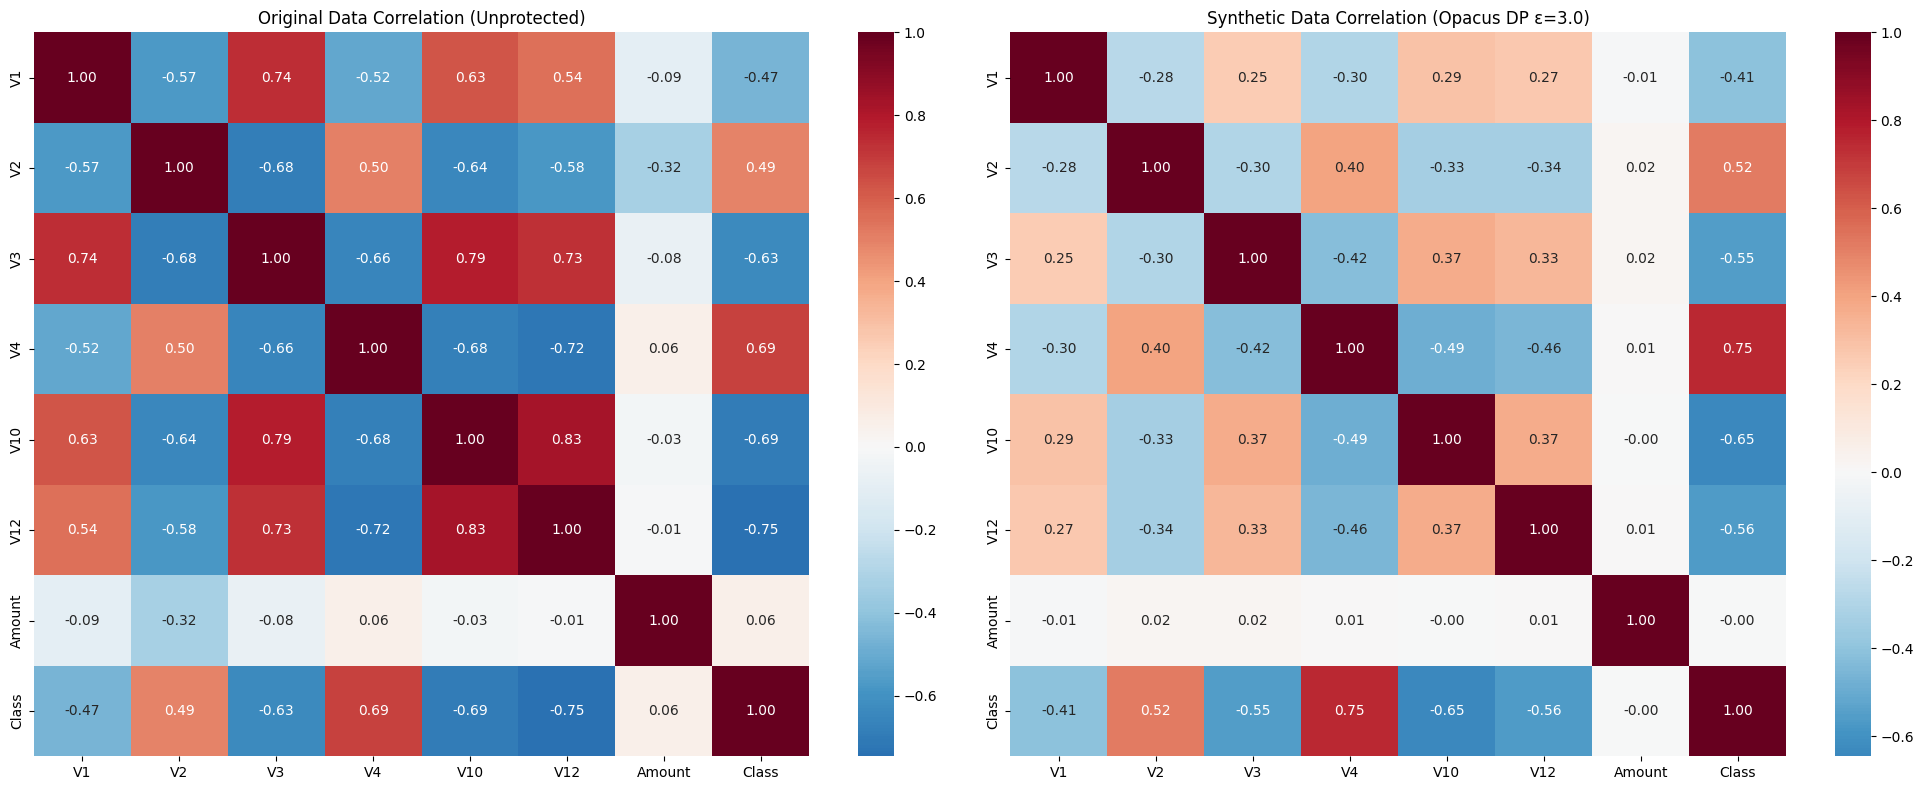

[5/6] 评估数据保真度...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:01<00:00, 20.55it/s]|
Column Shapes Score: 71.24%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:03<00:00, 122.76it/s]|
Column Pair Trends Score: 78.49%

Overall Score (Average): 74.86%

[6/6] 评估下游 ML 模型效能 (Utility)...

差分隐私等级: ε = 3.0
统计相似度得分: 74.86%
欺诈检测模型 AUC: 0.9516


In [48]:
import pandas as pd
import numpy as np
import torch
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from ctgan import CTGAN
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from opacus import PrivacyEngine

warnings.filterwarnings('ignore')

# ==========================================
# 核心类：动态注入 Opacus 的 TrueOpacusCTGAN
# ==========================================
class TrueOpacusCTGAN(CTGAN):
    def __init__(self, epsilon=3.0, delta=1e-5, max_grad_norm=1.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_epsilon = epsilon
        self.target_delta = delta
        self.max_grad_norm = max_grad_norm

    def _train(self, data):
        """重写内部训练逻辑，在判别器更新前拦截梯度"""
        dataset = TensorDataset(torch.from_numpy(data).float())
        data_loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=True,
            drop_last=True
        )

        # 注入 Opacus PrivacyEngine
        privacy_engine = PrivacyEngine()

        # 核心：包装判别器。GAN的隐私性由判别器拦截真实数据决定
        self._discriminator, self._opt_dens, train_loader = privacy_engine.make_private_with_epsilon(
            module=self._discriminator,
            optimizer=self._opt_dens,
            data_loader=data_loader,
            target_epsilon=self.target_epsilon,
            target_delta=self.target_delta,
            epochs=self.epochs,
            max_grad_norm=self.max_grad_norm,
        )

        print(f"✅ Opacus DP-SGD 已激活 (ε={self.target_epsilon})")
        super()._train(data)

# ==========================================
# 流水线管理类：增加可视化功能
# ==========================================
class DP_Visual_Pipeline:
    def __init__(self, data_url, epsilon=3.0):
        self.data_url = data_url
        self.epsilon = epsilon
        self.real_data = None
        self.synthetic_data = None
        self.metadata = None

    def load_and_preprocess(self):
        print("[1/6] 加载信用卡数据集...")
        df = pd.read_csv(self.data_url)
        # 构造平衡样本集
        fraud = df[df['Class'] == 1]
        normal = df[df['Class'] == 0].sample(n=3000, random_state=42)
        self.real_data = pd.concat([fraud, normal]).sample(frac=1).reset_index(drop=True)

        self.metadata = SingleTableMetadata()
        self.metadata.detect_from_dataframe(self.real_data)
        self.metadata.update_column(column_name='Class', sdtype='categorical')
        print(f"数据加载完成。样本量: {len(self.real_data)}")

    def train_with_dp(self, epochs=40):
        print(f"[2/6] 启动真正差分隐私训练 (Opacus)...")
        start_time = time.time()
        self.model = TrueOpacusCTGAN(epsilon=self.epsilon, batch_size=400, epochs=epochs)
        self.model.fit(self.real_data, discrete_columns=['Class'])
        print(f"训练耗时: {time.time() - start_time:.2f} 秒")

    def generate_data(self, count=3000):
        print(f"[3/6] 采样生成隐私合成数据...")
        self.synthetic_data = self.model.sample(count)
        # 类型修正
        for col in self.synthetic_data.columns:
            self.synthetic_data[col] = pd.to_numeric(self.synthetic_data[col], errors='ignore')
        self.synthetic_data['Class'] = self.synthetic_data['Class'].round().astype(int)

    def plot_correlation_comparison(self):
        """[新增] 生成相关性对比图"""
        print("[4/6] 绘制相关性矩阵对比...")
        # 选取前 8 个主要特征进行对比，避免热图过载
        cols = ['V1', 'V2', 'V3', 'V4', 'V10', 'V12', 'Amount', 'Class']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        # 真实数据热图
        real_corr = self.real_data[cols].corr()
        sns.heatmap(real_corr, annot=True, cmap='RdBu_r', center=0, ax=ax1, fmt=".2f")
        ax1.set_title("Original Data Correlation (Unprotected)")

        # DP 合成数据热图
        syn_corr = self.synthetic_data[cols].corr()
        sns.heatmap(syn_corr, annot=True, cmap='RdBu_r', center=0, ax=ax2, fmt=".2f")
        ax2.set_title(f"Synthetic Data Correlation (Opacus DP ε={self.epsilon})")

        plt.tight_layout()
        plt.show()

    def evaluate_performance(self):
        print("[5/6] 评估数据保真度...")
        quality = evaluate_quality(self.real_data, self.synthetic_data, self.metadata)

        print("[6/6] 评估下游 ML 模型效能 (Utility)...")
        X_syn = self.synthetic_data.drop('Class', axis=1)
        y_syn = self.synthetic_data['Class']
        X_test = self.real_data.drop('Class', axis=1)
        y_test = self.real_data['Class']

        gbm = GradientBoostingClassifier(random_state=42).fit(X_syn, y_syn)
        auc = roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1])

        print("\n" + "="*45)
        print(f"差分隐私等级: ε = {self.epsilon}")
        print(f"统计相似度得分: {quality.get_score():.2%}")
        print(f"欺诈检测模型 AUC: {auc:.4f}")
        print("="*45)

# ==========================================
# 运行
# ==========================================
if __name__ == "__main__":
    URL = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

    # 工业界常用的 epsilon 平衡点 (3.0)
    pipeline = DP_Visual_Pipeline(URL, epsilon=3.0)
    pipeline.load_and_preprocess()
    pipeline.train_with_dp(epochs=100)
    pipeline.generate_data(3000)
    pipeline.plot_correlation_comparison() # 展示对比
    pipeline.evaluate_performance()